# **Tiền Xử lí dữ liệu**

<a id="toc"></a>
# **MỤC LỤC**
***

**1. <a href='#1'>KHỞI TẠO VÀ TẢI DỮ LIỆU</a>**
> * <a href='#1.1'>1.1. Tải thư viện</a>
> * <a href='#1.2'>1.2. Đọc dữ liệu</a>

**2. <a href='#2'>TỔNG QUAN DỮ LIỆU</a>**
> * <a href='#2.1'>2.1. Kiểm tra tổng quan (Info, Null, Types)</a>
> * <a href='#2.2'>2.2. Phân tích phân phối & Outlier</a>

**3. <a href='#3'>XỬ LÝ DỮ LIỆU</a>**
> * <a href='#3.1'>3.1. Làm sạch dữ liệu</a>
> * <a href='#3.2'>3.2. Feature Engineering</a>
> * <a href='#3.3'>3.3. Xử lý Outlier</a>
> * <a href='#3.4'>3.4. Mã hóa và Chuẩn hóa</a>
> * <a href='#3.5'>3.5. Xử lí đa cộng tuyến</a>
> * <a href='#3.6'>3.6. Chọn lọc thuộc tính</a>

**4. <a href='#4'>PHÂN TÍCH TƯƠNG QUAN</a>**

**5. <a href='#5'>XUẤT DỮ LIỆU</a>**

***

***

## <a id='1'>1. Khởi tạo và Tải dữ liệu</a> 


### <a id='1.1'>1.1. Tải thư viện</a> 
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Bước đầu tiên là nhập các thư viện cần thiết cho việc xử lý dữ liệu (Pandas, Numpy) và trực quan hóa cơ bản (Matplotlib, Seaborn). Sau đó, chúng ta sẽ tải bộ dữ liệu `WA_Fn-UseC_-HR-Employee-Attrition.csv` vào DataFrame.

In [3]:
#TODO 1: Nhập thư viện và dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import warnings
from imblearn.over_sampling import SMOTE #
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline

### <a id='1.2'>1.2. Đọc dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

In [4]:
#TODO 2: Đọc dữ liệu
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

file_path = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## <a id='2'>2. Tổng quan dữ liệu và tìm ngoại lai</a>


### <a id='2.1'>2.1. Tổng quan dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Trước khi xử lý, ta cần nắm bắt kích thước dữ liệu, kiểu dữ liệu của từng thuộc tính và kiểm tra sơ bộ các giá trị thống kê. Điều này giúp xác định xem dữ liệu có chứa giá trị null hay không và định dạng đã chuẩn chưa.

In [5]:
#TODO 3: Tổng quan dữ liệu 
# Kiểm tra kích thước dữ liệu (số dòng, số cột)
print(f"Kích thước dataset: {df.shape}")

# Kiểm tra thông tin kiểu dữ liệu và giá trị thiếu (null)
df.info()

# Thống kê mô tả cho các biến định lượng
df.describe()

Kích thước dataset: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### <a id='2.2'>2.2. Phân tích phân phối và phát hiện ngoại lai</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>
Trước khi đi vào xử lý chi tiết, nhóm tiến hành kiểm tra phân phối của các biến định lượng quan trọng như `MonthlyIncome` (Thu nhập), `TotalWorkingYears` (Tổng số năm đi làm), và `YearsAtCompany` (Thâm niên).

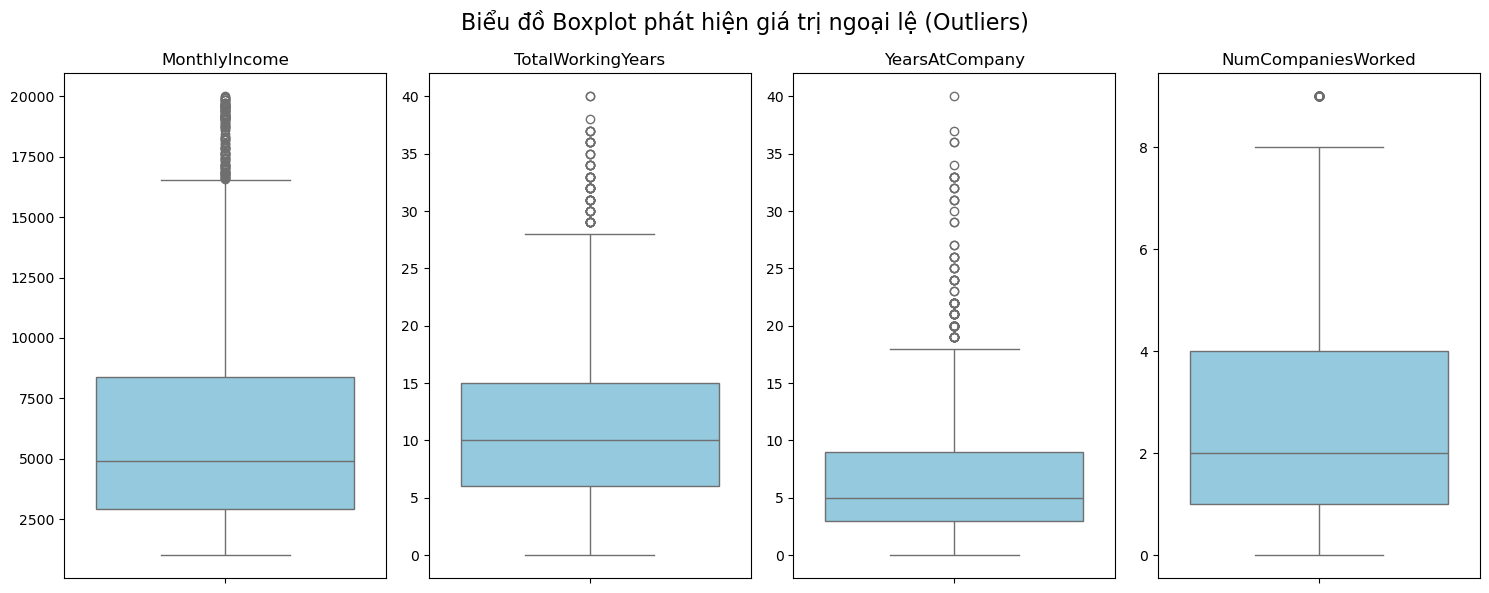

Biến 'MonthlyIncome': Phát hiện 114 giá trị ngoại lệ (>16581.0)
Biến 'TotalWorkingYears': Phát hiện 63 giá trị ngoại lệ (>28.5)
Biến 'YearsAtCompany': Phát hiện 104 giá trị ngoại lệ (>18.0)
Biến 'NumCompaniesWorked': Phát hiện 52 giá trị ngoại lệ (>8.5)


In [6]:
#TODO 4: Phân phối và phát hiện ngoại lai
# Chọn các biến định lượng liên tục (Continuous variables) 
# Đây là các biến thường có outlier
continuous_vars = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']

# Vẽ biểu đồ Boxplot để trực quan hóa Outliers
plt.figure(figsize=(15, 6))
plt.suptitle("Biểu đồ Boxplot phát hiện giá trị ngoại lệ (Outliers)", fontsize=16)

for i, col in enumerate(continuous_vars):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
    plt.ylabel('')

plt.tight_layout()
plt.show()

# Tính toán số lượng Outlier dựa trên IQR (để đưa vào báo cáo)
for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = df[df[col] > upper_bound].shape[0]
    print(f"Biến '{col}': Phát hiện {outliers_count} giá trị ngoại lệ (>{upper_bound})")

**Nhận xét:**
* **MonthlyIncome:** Xuất hiện nhiều điểm ngoại lai (Outliers) ở phía trên. Điều này phản ánh thực tế là một số ít nhân viên (Quản lý cấp cao, Giám đốc) có mức lương vượt trội so với mặt bằng chung.
* **YearsAtCompany & TotalWorkingYears:** Cũng có đuôi dài về phía giá trị lớn, đại diện cho nhóm nhân viên thâm niên cao.
* **Quyết định xử lý:** Vì chúng ta sẽ sử dụng các mô hình cây (như Random Forest) có khả năng chịu nhiễu tốt, và nhóm lương cao/thâm niên cao là nhóm quan trọng cần giữ chân, nên ta sẽ **không xóa bỏ** các dòng này mà sử dụng phương pháp **Capping (chặn trên)** hoặc giữ nguyên tùy theo thuật toán được chọn ở bước sau.

## <a id='3'>3. Xử lí dữ liệu</a>


### <a id='3.1'>3.1. Làm sạch dữ liệu</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Dựa trên kết quả kiểm tra sơ bộ, quy trình làm sạch dữ liệu bao gồm:
1.  **Xử lý giá trị thiếu (Null):** Kiểm tra lại lần cuối, nếu có sẽ điền bằng giá trị trung bình (Mean).
2.  **Xử lý trùng lặp:** Loại bỏ các dòng dữ liệu bị trùng hoàn toàn (Duplicate rows).
3.  **Loại bỏ thuộc tính vô nghĩa:** Xóa các cột có phương sai bằng 0 (chỉ có 1 giá trị duy nhất) như `EmployeeCount`, `StandardHours`, `Over18` và cột định danh `EmployeeNumber` không có giá trị dự báo.


In [7]:
#TODO 5: Xóa các cột không nhiều ảnh hưởng đến dữ liệu và tìm các dữ liệu bị thiếu
# 1. Kiểm tra null
if df.isnull().sum().sum() == 0:
    print("Dữ liệu sạch, không có giá trị thiếu (Null).")
else:
    df.fillna(df.mean(), inplace=True) # Điền mean nếu có (dự phòng)

# 2. Xóa trùng lặp
df.drop_duplicates(inplace=True)

# 3. Xóa cột thừa
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 4. Mã hóa biến mục tiêu 'Attrition' ngay từ đầu để tiện phân tích
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

print(f"Kích thước sau khi làm sạch: {df.shape}")

Dữ liệu sạch, không có giá trị thiếu (Null).
Kích thước sau khi làm sạch: (1470, 31)


### <a id='3.2'>3.2. Kỹ thuật tạo đặc trưng</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Dựa trên kiến thức nghiệp vụ (Domain Knowledge), nhóm thực hiện tạo thêm các biến phái sinh để làm nổi bật các mẫu (patterns) tiềm ẩn:

* **Các chỉ số tương đối:**
    * `Income_Rel_Role`: Tỷ lệ lương so với mức trung bình của vị trí đó (phát hiện người bị trả lương thấp).
    * `Income_Distance`: Tỷ lệ giữa thu nhập và khoảng cách đi làm (Trade-off).
    * `PromotionStagnation`: Mức độ trì trệ thăng tiến (Số năm không thăng chức / Thâm niên).
    * `Loyalty`: Chỉ số trung thành (Thâm niên tại cty / Tổng số năm đi làm).
    * `Stability`: Độ ổn định vị trí (Năm ở vị trí hiện tại / Thâm niên tại cty).

* **Các chỉ số tổng hợp:**
    * `TotalSatisfaction`: Điểm hài lòng trung bình (Môi trường + Công việc + Quan hệ + Cân bằng cuộc sống).

* **Các nhóm nhân viên đặc thù (Biến Binary 0/1):**
    * `SalesDpt`: Nhân viên thuộc phòng Sales (thường áp lực cao).
    * `JobInvCut`: Nhóm ít tham gia vào công việc (JobInvolvement < 2.5).
    * `MoovingPeople`: Nhóm hay nhảy việc (đã làm > 4 công ty).
    * `LongDisJobS1`: Nhóm rủi ro (Nhà xa > 11km VÀ Không hài lòng công việc).
    * `YoungAndBadPaid`: Nhóm rủi ro cao (Trẻ tuổi < 35 VÀ Lương thấp < 3500$).
    * `Engaged`: Nhóm ổn định (Tuổi > 35 VÀ Đã kết hôn).

* **Phân nhóm (Binning):**
    * `AgeGroup`: Nhóm tuổi (Young, Middle, Senior).
    * `IncomeRange`: Nhóm thu nhập (Low, Medium, High, Very High).

In [8]:
#TODO 6: Tạo đặc trưng mới
# Tỷ lệ thu nhập so với mức trung bình của vị trí (JobRole)
df['AvgIncome_Role'] = df.groupby('JobRole')['MonthlyIncome'].transform('mean')
df['Income_Rel_Role'] = df['MonthlyIncome'] / df['AvgIncome_Role']

# Mức độ "trì trệ" thăng tiến (Số năm không thăng chức / Thâm niên)
df['PromotionStagnation'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)

# Chỉ số trung thành (Loyalty)
df['Loyalty'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

# Tổng hợp mức độ hài lòng (Engagement Score)
df['TotalSatisfaction'] = (df['EnvironmentSatisfaction'] + 
                           df['JobSatisfaction'] + 
                           df['RelationshipSatisfaction'] + 
                           df['WorkLifeBalance']) / 4

# Độ ổn định công việc (Stability)
df['Stability'] = df['YearsInCurrentRole'] / (df['YearsAtCompany'] + 1e-5)


# Thuộc phòng Sales (Thường áp lực cao)
df['SalesDpt'] = (df['Department'] == 'Sales').astype(int)

# Ít tham gia công việc (< 2.5)
df['JobInvCut'] = (df['JobInvolvement'] < 2.5).astype(int)

# Người hay nhảy việc (> 4 công ty)
df['MoovingPeople'] = (df['NumCompaniesWorked'] > 4).astype(int)

# Nhóm rủi ro: Nhà xa (>11km) VÀ Không hài lòng công việc (Mức 1)
df['LongDisJobS1'] = ((df['DistanceFromHome'] > 11) & (df['JobSatisfaction'] == 1)).astype(int)

# Nhóm rủi ro: Trẻ tuổi (23-35) VÀ Lương thấp (<3500)
df['YoungAndBadPaid'] = ((df['Age'] > 23) & (df['Age'] < 35) & (df['MonthlyIncome'] < 3500)).astype(int)

# Nhóm ổn định: Tuổi > 35 và Đã kết hôn/Có gia đình
df['Engaged'] = ((df['Age'] > 35) & (df['MaritalStatus'] != 'Single')).astype(int)

# Tỷ lệ Thu nhập trên Khoảng cách đi lại
df['Income_Distance'] = df['MonthlyIncome'] / (df['DistanceFromHome'] + 1)


# Nhóm độ tuổi
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 45, 60], labels=['Young', 'Middle', 'Senior'])

# Nhóm thu nhập
df['IncomeRange'] = pd.qcut(df['MonthlyIncome'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Xóa cột trung gian
df.drop(columns=['AvgIncome_Role'], inplace=True, errors='ignore')

print("Đã hoàn thành tạo đặc trưng mới.")
display(df[['Income_Rel_Role', 'PromotionStagnation', 'YoungAndBadPaid', 'AgeGroup']].head())
display(df.head())

Đã hoàn thành tạo đặc trưng mới.


,Income_Rel_Role,PromotionStagnation,YoungAndBadPaid,AgeGroup
0,0.865505,0.000000,0,Middle
1,1.583347,0.090909,0,Senior
2,0.645626,0.000000,0,Middle
3,0.897847,0.333333,1,Middle
4,1.071306,0.666667,1,Young


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Income_Rel_Role,PromotionStagnation,Loyalty,TotalSatisfaction,Stability,SalesDpt,JobInvCut,MoovingPeople,LongDisJobS1,YoungAndBadPaid,Engaged,Income_Distance,AgeGroup,IncomeRange
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5,0.865505,0.000000,0.666667,2.00,0.666666,1,0,1,0,0,0,2996.500000,Middle,High
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7,1.583347,0.090909,0.909091,3.00,0.699999,0,1,0,0,0,1,570.000000,Senior,High
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0,0.645626,0.000000,0.000000,3.00,0.000000,0,1,1,0,0,0,696.666667,Middle,Low
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0,0.897847,0.333333,0.888889,3.25,0.874999,0,0,0,0,1,0,727.250000,Middle,Low
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2,1.071306,0.666667,0.285714,2.50,0.999995,0,0,1,0,1,0,1156.000000,Young,Medium


### <a id='3.3'>3.3. Xử lý Ngoại lệ (Outliers) & Phân phối lệch (Skewness)</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

**Chiến lược xử lý:**
1.  **Xử lý Ngoại lệ (Outliers):**
    * Thay vì xóa bỏ các dòng dữ liệu (có thể làm mất thông tin quan trọng của nhóm nhân sự cấp cao), nhóm sử dụng phương pháp **Capping (Chặn trên)**.
    * Các giá trị vượt quá ngưỡng $Q3 + 1.5 \times IQR$ sẽ được gán bằng giá trị ngưỡng đó.
    * Áp dụng cho: `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `NumCompaniesWorked`.

2.  **Xử lý Phân phối lệch (Skewness):**
    * Biến `MonthlyIncome` thường bị lệch phải (Right-skewed). Nhóm áp dụng **Log Transformation** (`np.log1p`) để đưa dữ liệu về dạng gần chuẩn hơn, giúp các mô hình hồi quy hoạt động tốt hơn.

In [9]:
#TODO 7: Xử lí ngoại lệ
# Hàm xử lý ngoại lệ
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    # Chỉ xử lý cận trên (Upper) vì dữ liệu nhân sự thường bị lệch về phía cao
    return series.clip(upper=upper_bound)

# Áp dụng cho các cột đã phát hiện ở Mục 2
cols_with_outliers = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']

for col in cols_with_outliers:
    df[col] = cap_outliers(df[col])

print(f"Đã hoàn tất xử lý ngoại lệ cho các biến: {cols_with_outliers}")

Đã hoàn tất xử lý ngoại lệ cho các biến: ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'NumCompaniesWorked']


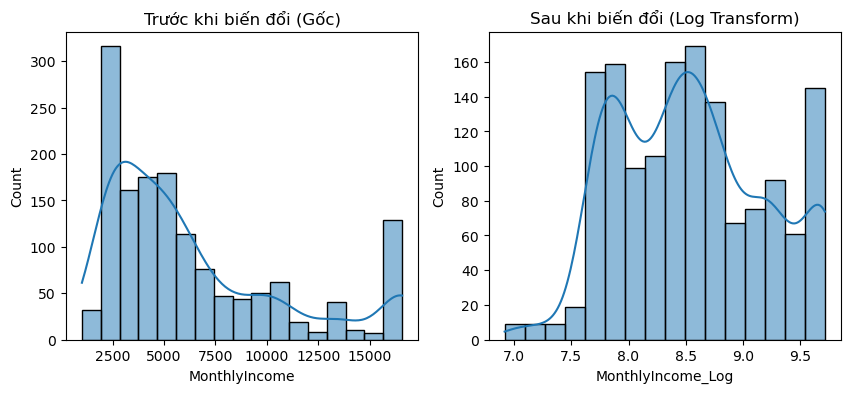

Đã xử lý độ lệch cho MonthlyIncome.


In [10]:
# TODO :Xử lí độ lệch dữ liệu
# [BỔ SUNG] Kiểm tra và xử lý độ lệch cho biến 'MonthlyIncome'
# Biến thu nhập thường bị lệch phải (Right-skewed) nặng
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title('Trước khi biến đổi (Gốc)')

# Áp dụng Log Transformation (np.log1p để tránh lỗi log(0))
df['MonthlyIncome_Log'] = np.log1p(df['MonthlyIncome'])

plt.subplot(1, 2, 2)
sns.histplot(df['MonthlyIncome_Log'], kde=True)
plt.title('Sau khi biến đổi (Log Transform)')
plt.show()

# Xóa cột cũ, giữ cột Log
df.drop('MonthlyIncome', axis=1, inplace=True)
df.rename(columns={'MonthlyIncome_Log': 'MonthlyIncome'}, inplace=True)
print("Đã xử lý độ lệch cho MonthlyIncome.")

### <a id='3.4'>3.4. Mã hóa & Xử lí đa cộng tuyến</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

**Quy trình thực hiện:**
1.  **Mã hóa One-Hot:** Chuyển đổi toàn bộ các biến phân loại (Categorical) sang dạng số (Binary 0/1) để máy tính có thể hiểu được. Sử dụng `drop_first=True` để tránh bẫy đa cộng tuyến giả.
2.  **Xử lý Đa cộng tuyến (Multicollinearity):**
    * Tính toán ma trận tương quan giữa các biến độc lập.
    * Loại bỏ các biến có hệ số tương quan cao (**> 0.8**) để giảm nhiễu và tăng tính ổn định cho mô hình.
    * *Ví dụ:* Nếu `MonthlyIncome` tương quan quá cao với `JobLevel`, một trong hai sẽ bị loại bỏ.

In [11]:
# --- 1. MÃ HÓA (ENCODING) ---
# Mã hóa One-Hot cho toàn bộ dữ liệu trước (vì mã hóa không gây rò rỉ thông tin thống kê)
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df_encoded.astype(float) # Đảm bảo định dạng số

# --- 2. XỬ LÝ ĐA CỘNG TUYẾN (MULTICOLLINEARITY) ---
# Thực hiện trước khi chia để giảm số lượng cột không cần thiết
X_temp = df_encoded.drop('Attrition', axis=1)
corr_matrix = X_temp.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

df_encoded.drop(columns=to_drop, axis=1, inplace=True)
print(f"Đã loại bỏ {len(to_drop)} cột do đa cộng tuyến: {to_drop}")

Đã loại bỏ 8 cột do đa cộng tuyến: ['YearsInCurrentRole', 'YearsWithCurrManager', 'JobInvCut', 'MoovingPeople', 'MonthlyIncome', 'Department_Research & Development', 'Department_Sales', 'JobRole_Sales Executive']


### <a id='3.5'>3.5. Chuẩn hóa dữ liệu và cân bằng dữ liệu bằng SMOTE</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Đây là bước quan trọng nhất để **tránh rò rỉ dữ liệu (Data Leakage)**:

1.  **Chia tập Train/Test:** Tách dữ liệu thành 80% Train và 20% Test *trước* khi thực hiện bất kỳ kỹ thuật xử lý nào liên quan đến thống kê tổng thể.
2.  **Chuẩn hóa (Standard Scaling):**
    * `Fit` bộ chuẩn hóa chỉ trên tập **Train**.
    * Dùng tham số đó để `Transform` cho cả tập Train và tập Test.
    * Điều này đảm bảo mô hình không "biết trước" phân phối của tập Test.
3.  **Cân bằng dữ liệu (SMOTE):**
    * Dữ liệu nhân sự thường mất cân bằng (số người nghỉ việc ít hơn người ở lại).
    * Sử dụng **SMOTE** để sinh mẫu nhân tạo cho nhóm thiểu số.
    * **Lưu ý:** Chỉ áp dụng SMOTE trên tập **Train**, giữ nguyên tập Test để đánh giá khách quan.

In [12]:


# --- 3. CHIA TRAIN / TEST (QUAN TRỌNG: Làm bước này trước khi Scale/SMOTE) ---
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Chia tỷ lệ 80% Train - 20% Test (có stratify để giữ tỷ lệ nhãn giống nhau)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# --- 4. CHUẨN HÓA (SCALING) - FIX DATA LEAKAGE ---
# Chỉ fit scaler trên tập Train, sau đó transform cả Train và Test
scaler = StandardScaler()

# Lấy danh sách các cột cần scale (loại bỏ các cột nhị phân 0/1)
cols_to_scale = [col for col in X_train.columns if X_train[col].nunique() > 2]

# Fit & Transform trên Train
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Chỉ Transform trên Test (Sử dụng tham số từ Train)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Đã hoàn tất chuẩn hóa dữ liệu (StandardScaler).")


Kích thước tập Train: (1176, 53)
Kích thước tập Test: (294, 53)
Đã hoàn tất chuẩn hóa dữ liệu (StandardScaler).


In [13]:
# [BỔ SUNG] Xử lý mất cân bằng dữ liệu bằng SMOTE
# Chỉ áp dụng trên tập TRAIN (Không được chạm vào tập Test)

print("Tỷ lệ nhãn trước SMOTE (Train):")
print(y_train.value_counts(normalize=True))

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nTỷ lệ nhãn sau SMOTE (Train):")
print(y_train_resampled.value_counts(normalize=True))
print(f"Kích thước tập Train mới: {X_train_resampled.shape}")

Tỷ lệ nhãn trước SMOTE (Train):
Attrition
0.0    0.838435
1.0    0.161565
Name: proportion, dtype: float64

Tỷ lệ nhãn sau SMOTE (Train):
Attrition
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64
Kích thước tập Train mới: (1972, 53)


  File "c:\Users\kimho\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\kimho\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kimho\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kimho\anaconda3\Lib\subprocess.

### <a id='3.6'>3.6. Chọn lọc thuộc tính</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>


Sử dụng thuật toán **Random Forest Classifier** trên tập dữ liệu đã cân bằng (SMOTE) để đánh giá mức độ quan trọng của từng biến:

* **Mục tiêu:** Xác định Top 20-25 đặc trưng đóng góp nhiều nhất vào khả năng dự báo.
* **Kết quả:** Loại bỏ các biến rác (noise), giúp mô hình nhẹ hơn và tránh Overfitting. Danh sách các cột tốt nhất sẽ được dùng để lọc dữ liệu trước khi xuất file.

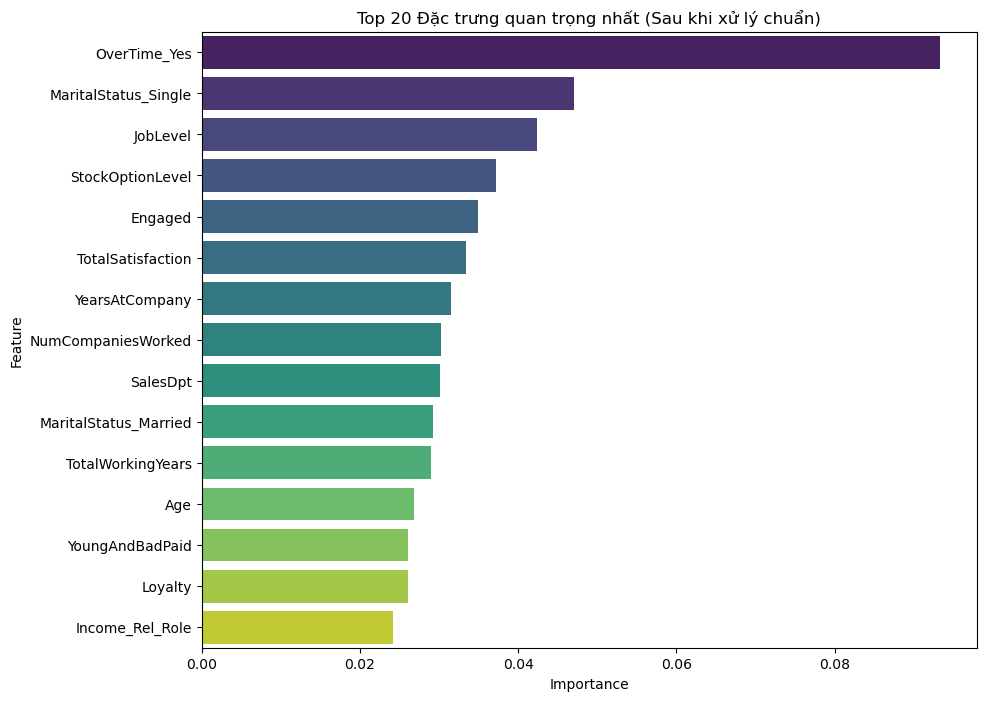

Các cột được chọn: ['OverTime_Yes', 'MaritalStatus_Single', 'JobLevel', 'StockOptionLevel', 'Engaged', 'TotalSatisfaction', 'YearsAtCompany', 'NumCompaniesWorked', 'SalesDpt', 'MaritalStatus_Married', 'TotalWorkingYears', 'Age', 'YoungAndBadPaid', 'Loyalty', 'Income_Rel_Role']


In [18]:
# Đánh giá độ quan trọng đặc trưng (Dùng dữ liệu đã SMOTE)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# Lấy Top 20 đặc trưng quan trọng nhất
importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
top_features = importances.sort_values(by='Importance', ascending=False).head(15)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 20 Đặc trưng quan trọng nhất (Sau khi xử lý chuẩn)')
plt.show()

# Lưu danh sách các cột tốt nhất
selected_columns = top_features['Feature'].tolist()
print("Các cột được chọn:", selected_columns)

**Đánh giá mức độ quan trọng của đặc trưng (Feature Importance):**

Dựa vào biểu đồ trên, ta xác định được các yếu tố then chốt ("Key Drivers") ảnh hưởng mạnh nhất đến quyết định nghỉ việc:
1.  **OverTime (Làm thêm giờ):** Thường là yếu tố số 1. Nhân viên phải làm thêm giờ nhiều có xu hướng nghỉ việc cao.
2.  **MonthlyIncome / Income_Rel_Role:** Thu nhập (đặc biệt là thu nhập so với vị trí) đóng vai trò lớn.
3.  **Age / TotalWorkingYears:** Nhóm nhân viên trẻ và ít thâm niên thường kém ổn định hơn.
4.  **StockOptionLevel:** Chế độ đãi ngộ cổ phiếu có tác động giữ chân nhân viên rõ rệt.

> **Kết luận:** Các biến mới được tạo ra (như `Income_Rel_Role`) đã lọt vào top quan trọng, chứng tỏ bước Feature Engineering đã hiệu quả.

### 3.7. Thẩm định độ ổn định của dữ liệu (Stability Validation)


Trước khi xuất dữ liệu, nhóm thực hiện **Stratified K-Fold Cross-Validation** (với K=5) để kiểm chứng độ ổn định của các đặc trưng đã chọn.

* **Phương pháp:** Sử dụng `ImbPipeline` để đảm bảo quy trình **SMOTE -> Scaling -> Modeling** được thực hiện khép kín trong từng fold.
* **Mục tiêu:** Đảm bảo việc xử lý mất cân bằng dữ liệu không gây ra hiện tượng rò rỉ (Data Leakage) và đánh giá xem mô hình có hoạt động ổn định trên các tập dữ liệu con khác nhau hay không.

In [19]:
# --- BƯỚC BỔ SUNG: KIỂM TRA ĐỘ ỔN ĐỊNH BẰNG K-FOLD CROSS-VALIDATION ---
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
# Lưu ý: Phải dùng Pipeline của imblearn để SMOTE chỉ chạy trên tập Train của từng fold

# 1. Chuẩn bị dữ liệu cho K-Fold
# Chúng ta dùng X_train, y_train gốc (chưa qua SMOTE toàn cục) để đảm bảo khách quan
# Chỉ lấy các cột đã được chọn ở bước trên
X_train_cv = X_train[selected_columns]
y_train_cv = y_train

# 2. Xây dựng Pipeline chuẩn
# Quy trình sẽ là: Trong mỗi fold -> Tự động SMOTE -> Tự động Scale -> Chạy Model
cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 3. Thiết lập Stratified K-Fold (5 phần)
# Stratified giúp giữ nguyên tỷ lệ nghỉ việc/ở lại trong mỗi phần chia
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Thực hiện đánh giá
print("Đang chạy K-Fold Cross-Validation (5-Folds)...")
# Sử dụng 'f1' score vì dữ liệu bị lệch (Accuracy không phản ánh đúng)
cv_scores = cross_val_score(cv_pipeline, X_train_cv, y_train_cv, cv=kf, scoring='f1')

# 5. Kết quả
print(f"--- KẾT QUẢ THẨM ĐỊNH K-FOLD ---")
print(f"F1-Score từng lần chạy: {cv_scores}")
print(f"F1-Score trung bình:    {cv_scores.mean():.4f}")
print(f"Độ lệch chuẩn (Std):    {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("=> Đánh giá: Mô hình ổn định tốt, bộ đặc trưng đã chọn đáng tin cậy.")
else:
    print("=> Cảnh báo: Kết quả biến động mạnh. Cần xem lại các đặc trưng hoặc dữ liệu ngoại lai.")

Đang chạy K-Fold Cross-Validation (5-Folds)...
--- KẾT QUẢ THẨM ĐỊNH K-FOLD ---
F1-Score từng lần chạy: [0.5        0.38461538 0.47619048 0.48387097 0.52054795]
F1-Score trung bình:    0.4730
Độ lệch chuẩn (Std):    0.0468
=> Đánh giá: Mô hình ổn định tốt, bộ đặc trưng đã chọn đáng tin cậy.


## <a id='4'>4. Phân tích tương quan</a>
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Phân tích hệ số tương quan (Pearson Correlation) giữa các biến đặc trưng với biến mục tiêu `Attrition` để xác định các yếu tố tác động:

* **Nhóm tác động dương (Positive Correlation):** Các yếu tố càng cao thì nguy cơ nghỉ việc càng lớn (Cột màu đỏ).
* **Nhóm tác động âm (Negative Correlation):** Các yếu tố càng cao thì nhân viên càng gắn bó (Cột màu xanh).

Biểu đồ dưới đây trực quan hóa 15 yếu tố hàng đầu ở mỗi nhóm.

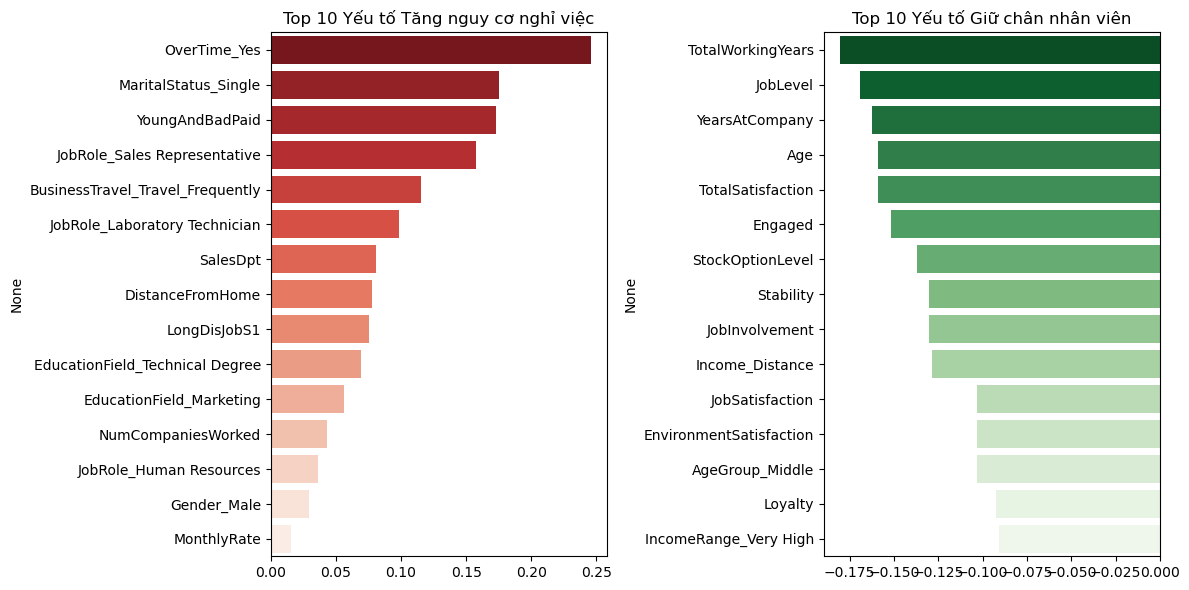

5 yếu tố ảnh hưởng tích cực mạnh nhất (Dễ nghỉ việc):
OverTime_Yes                        0.246118
MaritalStatus_Single                0.175419
YoungAndBadPaid                     0.172799
JobRole_Sales Representative        0.157234
BusinessTravel_Travel_Frequently    0.115143
Name: Attrition, dtype: float64

5 yếu tố ảnh hưởng tiêu cực mạnh nhất (Khó nghỉ việc):
TotalWorkingYears   -0.180628
JobLevel            -0.169105
YearsAtCompany      -0.162211
Age                 -0.159205
TotalSatisfaction   -0.159092
Name: Attrition, dtype: float64


In [20]:
#TODO 10: Đánh giá tương quan của các thuộc tính đến yếu tố nghỉ việc ('Attrition')
# 1. Tính toán ma trận tương quan trên dữ liệu đã mã hóa
# df_encoded đã bao gồm cả các biến số (đã chuẩn hóa) và biến phân loại (One-hot)
correlation_matrix = df_encoded.corr()

# 2. Lấy tương quan với biến mục tiêu 'Attrition'
attrition_corr = correlation_matrix['Attrition'].drop('Attrition')

# 3. Sắp xếp để thấy rõ nhất
top_positive = attrition_corr.sort_values(ascending=False).head(15)
top_negative = attrition_corr.sort_values(ascending=True).head(15)

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=top_positive.values, y=top_positive.index, palette='Reds_r')
plt.title('Top 10 Yếu tố Tăng nguy cơ nghỉ việc')

plt.subplot(1, 2, 2)
sns.barplot(x=top_negative.values, y=top_negative.index, palette='Greens_r')
plt.title('Top 10 Yếu tố Giữ chân nhân viên')

plt.tight_layout()
plt.show()
# In ra giá trị cụ thể để tham khảo
print("5 yếu tố ảnh hưởng tích cực mạnh nhất (Dễ nghỉ việc):")
print(top_positive.head(5))
print("\n5 yếu tố ảnh hưởng tiêu cực mạnh nhất (Khó nghỉ việc):")
print(top_negative.sort_values(ascending=True).head(5))


## <a id='5'>5. Xuất dữ liệu
<div style="text-align: right">
    <a href="#toc">⬆Quay lại Mục lục</a>
</div>

Xuất bộ dữ liệu đã qua xử lý thành 4 file riêng biệt để sẵn sàng cho giai đoạn Modeling (Huấn luyện mô hình):

1.  **`X_train.csv`**: Dữ liệu huấn luyện (Đã chọn lọc đặc trưng, đã chuẩn hóa, đã cân bằng SMOTE).
2.  **`y_train.csv`**: Nhãn huấn luyện (Đã cân bằng - SMOTE).
3.  **`X_test.csv`**: Dữ liệu kiểm thử (Đã chọn lọc đặc trưng, đã chuẩn hóa theo tập Train).
4.  **`y_test.csv`**: Nhãn kiểm thử (Dữ liệu thực tế, chưa can thiệp).



In [21]:
# Lọc dữ liệu theo các cột đã chọn
X_train_final = X_train_resampled[selected_columns]
X_test_final = X_test[selected_columns]

# Xuất ra CSV
X_train_final.to_csv('X_train.csv', index=False)
y_train_resampled.to_csv('y_train.csv', index=False)
X_test_final.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Đã xuất dữ liệu thành công:")
print("- X_train.csv (Dữ liệu train đã cân bằng, đã scale, chọn lọc đặc trưng)")
print("- y_train.csv (Nhãn train đã cân bằng)")
print("- X_test.csv  (Dữ liệu test giữ nguyên thực tế, đã scale theo train)")
print("- y_test.csv  (Nhãn test thực tế)")

Đã xuất dữ liệu thành công:
- X_train.csv (Dữ liệu train đã cân bằng, đã scale, chọn lọc đặc trưng)
- y_train.csv (Nhãn train đã cân bằng)
- X_test.csv  (Dữ liệu test giữ nguyên thực tế, đã scale theo train)
- y_test.csv  (Nhãn test thực tế)
